# Step 6 — Evaluate on DDPM Generated Images

Run the trained morphology CNN on all 10,000 DDPM-generated images, then produce the **final 4-panel figures** (one per parameter) comparing the real test set to the generated images.

**For generated images we have no ground truth morphology**, so the comparison is distributional:
- Top-left: scatter predicted vs true (real test set) with KDE
- Top-right: predicted morphology distribution — GT (blue) vs DDPM (red)
- Bottom-left: mean bias per true-value bin (real test set)
- Bottom-right: KL divergence + per-redshift-bin mean |residual| DDPM − GT

## 6.1 Imports & load Step 5 results

In [7]:
import os, sys, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.special import kl_div

HERE    = os.path.dirname(os.path.abspath("step6_evaluate_generated.ipynb"))
GEN_DIR = "/Users/wen/Desktop/project/lizarraga_2024-main/generated_images"
sys.path.insert(0, HERE)
from model import MorphCNN

TARGET_COLS  = ["g_ellipticity", "g_major_axis", "g_sersic_index", "g_isophotal_area"]
PARAM_LABELS = ["Ellipticity", "Major Axis (arcsec)", "Sérsic Index n", "Isophotal Area (px²)"]
PARAM_SHORT  = ["ellipticity", "major_axis", "sersic_index", "isophotal_area"]
DEVICE       = "mps" if torch.backends.mps.is_available() else "cpu"

with open(os.path.join(HERE, "normaliser.json")) as fp:
    NORM = json.load(fp)
with open(os.path.join(HERE, "image_stats.json")) as fp:
    img_stats = json.load(fp)

IMG_MEAN = torch.tensor(img_stats["mean"], dtype=torch.float32).view(5,1,1)
IMG_STD  = torch.tensor(img_stats["std"],  dtype=torch.float32).view(5,1,1)

def denormalise(arr):
    out = []
    for i, col in enumerate(TARGET_COLS):
        v = arr[:, i].copy()
        v = v * NORM[col]["std"] + NORM[col]["mean"]
        t = NORM[col]["transform"]
        if t == "log1p": v = np.expm1(v)
        elif t == "log":  v = np.exp(v)
        out.append(v)
    return np.stack(out, axis=1)

def sigma_nmad(r):
    return 1.4826 * np.median(np.abs(r - np.median(r)))

# load Step 5 results
test_preds = np.load(os.path.join(HERE, "test_preds.npy"))   # (N_test, 4)
test_true  = np.load(os.path.join(HERE, "test_true.npy"))    # (N_test, 4)
print(f"Loaded test results: {test_preds.shape[0]:,} galaxies")

Loaded test results: 40,891 galaxies


## 6.2 Inference on DDPM generated images

In [8]:
model = MorphCNN(n_outputs=4).to(DEVICE)
ckpt  = torch.load(os.path.join(HERE, "checkpoints", "best.pt"),
                   map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model"])
model.eval()

# handle both checkpoint formats: best.pt (val_loss) and epoch_XX.pt (val_losses list)
best_val = ckpt.get("val_loss") or min(ckpt.get("val_losses", [float("nan")]))
print(f"Model loaded  (epoch {ckpt['epoch']}, val_loss={best_val:.5f})")

pt_files   = sorted(f for f in os.listdir(GEN_DIR) if f.endswith(".pt"))
redshifts  = np.load(os.path.join(GEN_DIR, "generated_redshifts.npy"))
n_gen      = len(pt_files)
print(f"Generated images: {n_gen:,}  |  Redshifts: {redshifts.shape}")

BATCH = 256
gen_preds_norm = []

for s in range(0, n_gen, BATCH):
    batch_files = pt_files[s : s + BATCH]
    imgs = torch.stack([
        torch.load(os.path.join(GEN_DIR, fn), map_location="cpu", weights_only=True)
        for fn in batch_files
    ])
    imgs = (torch.arcsinh(imgs) - IMG_MEAN) / IMG_STD
    with torch.no_grad():
        gen_preds_norm.append(model(imgs.to(DEVICE)).cpu().numpy())
    if (s // BATCH) % 5 == 0:
        print(f"  {s + len(batch_files):>5,} / {n_gen}", end="\r")

gen_preds_norm = np.concatenate(gen_preds_norm)
gen_preds      = denormalise(gen_preds_norm)
print(f"\nDone. gen_preds shape: {gen_preds.shape}")

np.save(os.path.join(HERE, "gen_preds.npy"), gen_preds)
print("Saved gen_preds.npy")

Model loaded  (epoch 22, val_loss=0.03508)
Generated images: 10,000  |  Redshifts: (10000,)
  9,216 / 10000
Done. gen_preds shape: (10000, 4)
Saved gen_preds.npy


## 6.3 Final figures — one per parameter

Each figure:
- **Top-left:** scatter pred vs true (GT test set) + KDE
- **Top-right:** predicted distribution overlay — GT (blue) vs DDPM (red)
- **Bottom-left:** bias per bin ± σ_NMAD (GT test set)
- **Bottom-right:** mean |pred − true (GT)| per bin, GT vs DDPM side-by-side + KL divergence annotation

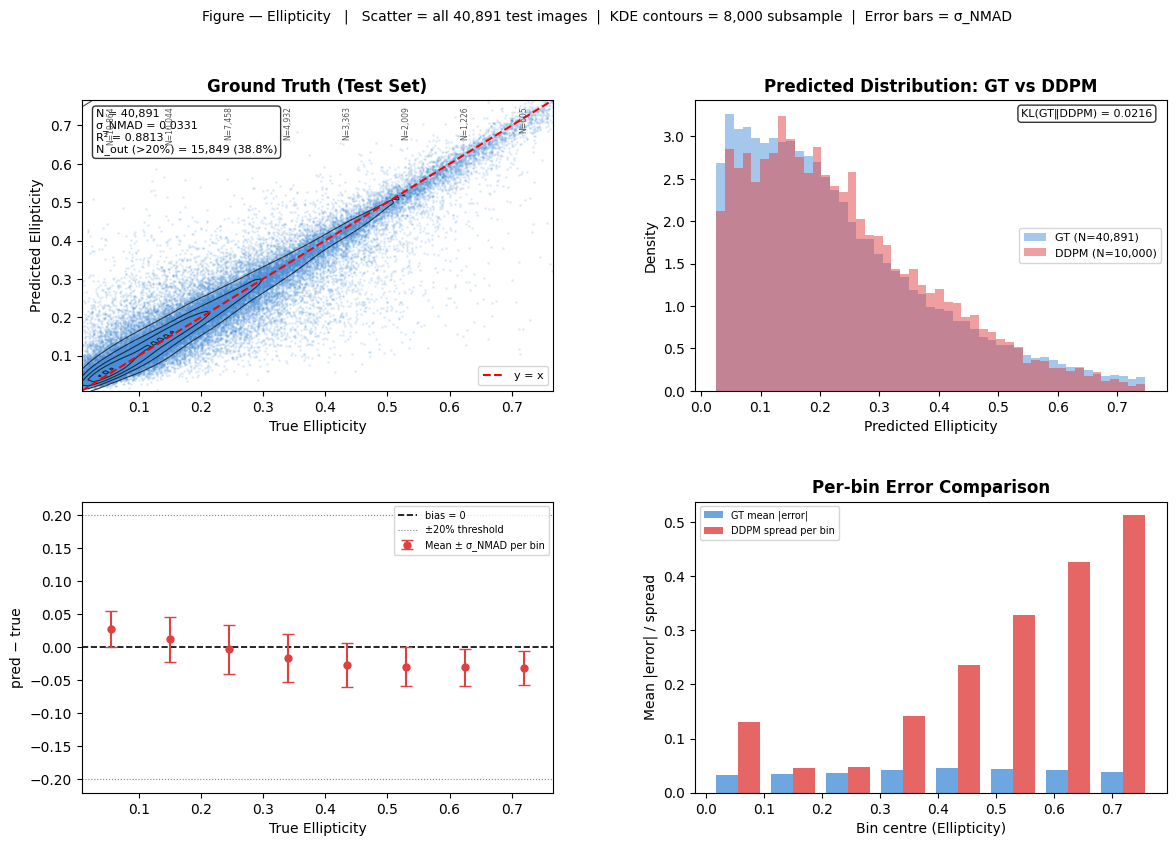

Saved eval_final_ellipticity.png   KL=0.0216



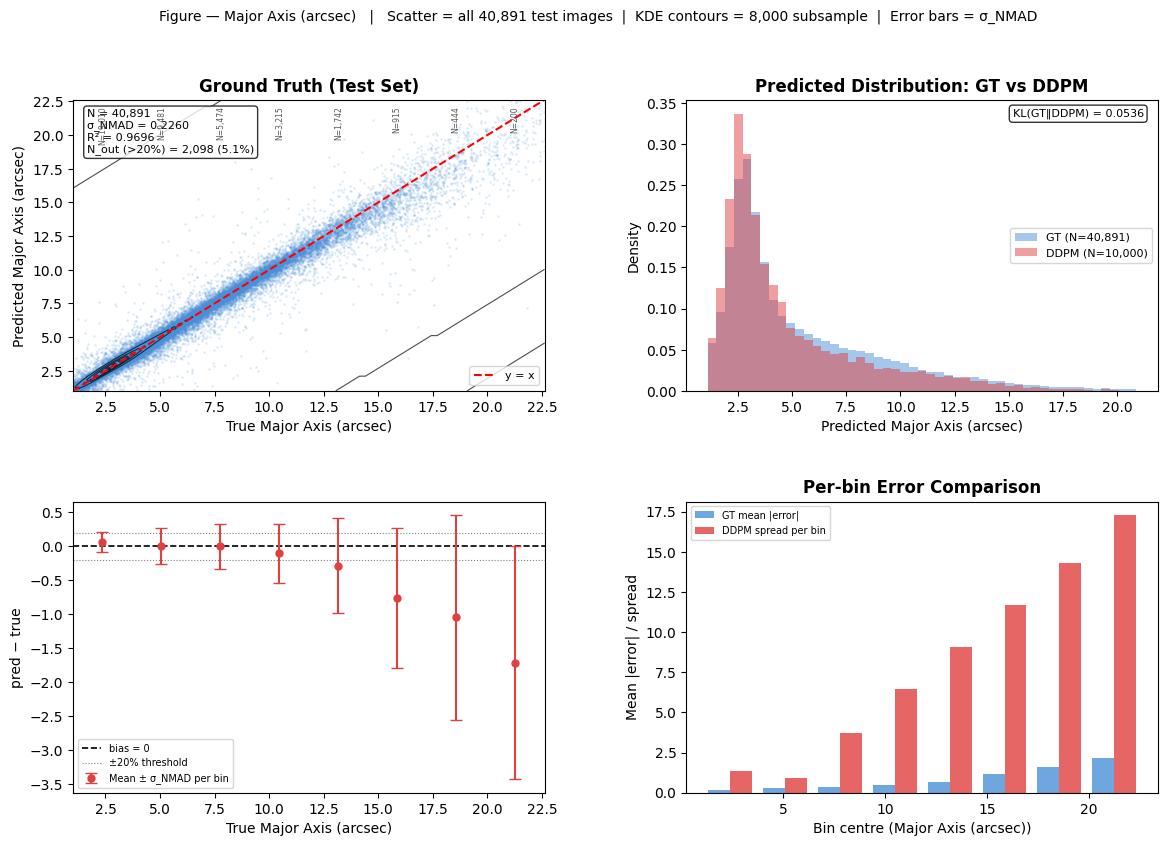

Saved eval_final_major_axis.png   KL=0.0536



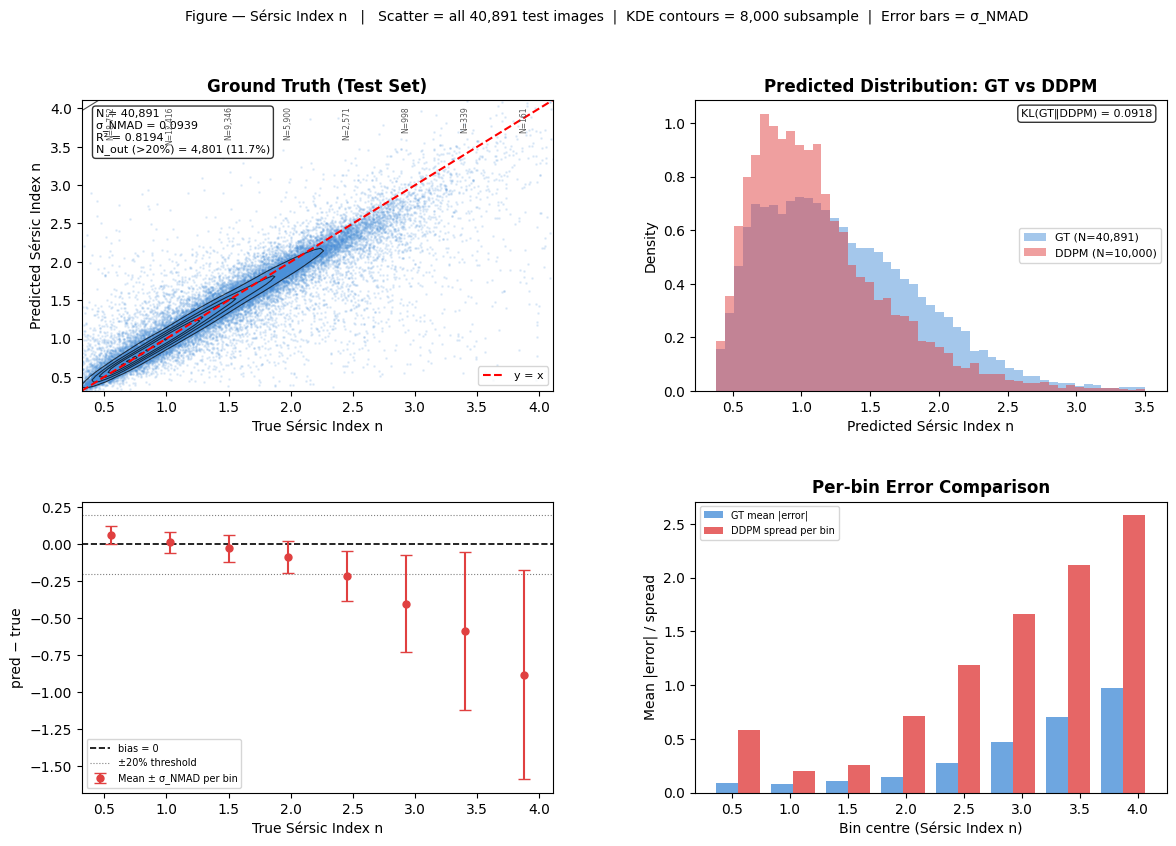

Saved eval_final_sersic_index.png   KL=0.0918



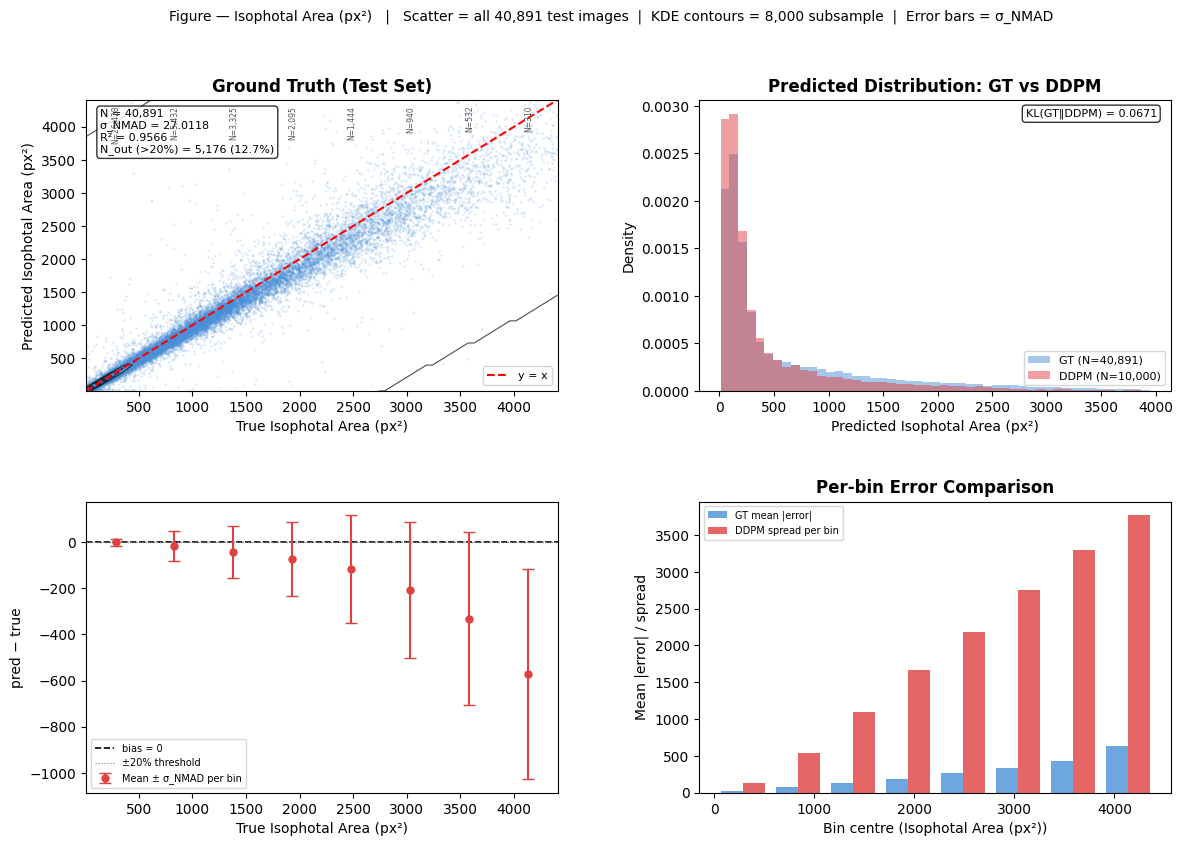

Saved eval_final_isophotal_area.png   KL=0.0671



In [9]:
def bin_stats(true, residuals, bins):
    cx, means, nmads, counts = [], [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (true >= lo) & (true < hi)
        if m.sum() < 5: continue
        r = residuals[m]
        cx.append(0.5*(lo+hi)); means.append(np.mean(r))
        nmads.append(sigma_nmad(r)); counts.append(m.sum())
    return map(np.array, (cx, means, nmads, counts))

def kl_divergence(p_samples, q_samples, n_bins=50):
    """Compute KL(P||Q) from samples via histogram."""
    lo = min(p_samples.min(), q_samples.min())
    hi = max(p_samples.max(), q_samples.max())
    bins = np.linspace(lo, hi, n_bins + 1)
    p_hist, _ = np.histogram(p_samples, bins=bins, density=True)
    q_hist, _ = np.histogram(q_samples, bins=bins, density=True)
    eps = 1e-10
    p_hist = p_hist + eps; q_hist = q_hist + eps
    p_hist /= p_hist.sum(); q_hist /= q_hist.sum()
    return float(np.sum(kl_div(p_hist, q_hist)))


rng   = np.random.default_rng(42)
KDE_N = 8000

for i, (col, label, short) in enumerate(zip(TARGET_COLS, PARAM_LABELS, PARAM_SHORT)):
    gt_pred = test_preds[:, i]    # CNN prediction on real test images
    gt_true = test_true[:, i]     # ground truth
    ddpm    = gen_preds[:, i]     # CNN prediction on DDPM images

    res = gt_pred - gt_true
    vlo, vhi = np.percentile(gt_true, 0.5), np.percentile(gt_true, 99.5)
    bins = np.linspace(vlo, vhi, 9)

    bx, bmean, bnmad, bcounts = bin_stats(gt_true, res, bins)
    bx2, babs_gt, _, _        = bin_stats(gt_true, np.abs(res), bins)

    # KL divergence (GT predicted vs DDPM predicted)
    kl = kl_divergence(gt_pred, ddpm)

    # KDE for scatter
    idx_kde = rng.choice(len(gt_true), KDE_N, replace=False)
    xy  = np.vstack([gt_true[idx_kde], gt_pred[idx_kde]])
    kde = gaussian_kde(xy, bw_method=0.15)
    xg, yg = np.mgrid[vlo:vhi:80j, vlo:vhi:80j]
    zg = kde(np.vstack([xg.ravel(), yg.ravel()])).reshape(80, 80)

    # ── figure ───────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 9))
    fig.suptitle(
        f"Figure — {label}   |   "
        f"Scatter = all {len(gt_true):,} test images  |  "
        f"KDE contours = {KDE_N:,} subsample  |  "
        f"Error bars = σ_NMAD",
        fontsize=10
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)
    ax_sc  = fig.add_subplot(gs[0, 0])
    ax_res = fig.add_subplot(gs[1, 0])
    ax_dist = fig.add_subplot(gs[0, 1])
    ax_bar  = fig.add_subplot(gs[1, 1])

    # ── top-left: scatter + KDE ──────────────────────────────────────────
    ax_sc.scatter(gt_true, gt_pred, s=1, alpha=0.12, color="#4a90d9", rasterized=True)
    ax_sc.contour(xg, yg, zg, levels=5, colors="k", linewidths=0.8, alpha=0.7)
    ax_sc.plot([vlo, vhi], [vlo, vhi], "r--", lw=1.5, label="y = x")
    ax_sc.set_xlim(vlo, vhi); ax_sc.set_ylim(vlo, vhi)
    ax_sc.set_xlabel(f"True {label}"); ax_sc.set_ylabel(f"Predicted {label}")
    ax_sc.set_title("Ground Truth (Test Set)", fontweight="bold")
    from sklearn.metrics import r2_score
    r2 = r2_score(gt_true, gt_pred)
    nmad_g = sigma_nmad(res)
    n_out  = np.sum(np.abs(res) / (np.abs(gt_true) + 1e-8) > 0.20)
    stats  = (f"N = {len(gt_true):,}\nσ_NMAD = {nmad_g:.4f}\n"
              f"R² = {r2:.4f}\nN_out (>20%) = {n_out:,} ({100*n_out/len(gt_true):.1f}%)")
    ax_sc.text(0.03, 0.97, stats, transform=ax_sc.transAxes, fontsize=8, va="top",
               bbox=dict(fc="white", alpha=0.8, boxstyle="round"))
    ax_sc.legend(fontsize=8, loc="lower right")
    for xc, cnt in zip(bx, bcounts):
        ax_sc.text(xc, vhi*0.98, f"N={cnt:,}", ha="center", va="top",
                   fontsize=5.5, color="#555", rotation=90)

    # ── bottom-left: bias per bin ────────────────────────────────────────
    ax_res.axhline(0,    color="k",    lw=1.2, ls="--", label="bias = 0")
    ax_res.axhline( 0.2, color="gray", lw=0.8, ls=":")
    ax_res.axhline(-0.2, color="gray", lw=0.8, ls=":", label="±20% threshold")
    ax_res.errorbar(bx, bmean, yerr=bnmad, fmt="o", color="#e04040",
                    capsize=4, ms=5, label="Mean ± σ_NMAD per bin")
    ax_res.set_xlabel(f"True {label}"); ax_res.set_ylabel("pred − true")
    ax_res.set_xlim(vlo, vhi); ax_res.legend(fontsize=7)

    # ── top-right: distribution overlay ─────────────────────────────────
    hist_bins = np.linspace(
        min(np.percentile(gt_pred, 0.5), np.percentile(ddpm, 0.5)),
        max(np.percentile(gt_pred, 99.5), np.percentile(ddpm, 99.5)),
        50
    )
    ax_dist.hist(gt_pred, bins=hist_bins, density=True, alpha=0.5,
                 color="#4a90d9", label=f"GT (N={len(gt_pred):,})")
    ax_dist.hist(ddpm,    bins=hist_bins, density=True, alpha=0.5,
                 color="#e04040", label=f"DDPM (N={len(ddpm):,})")
    ax_dist.set_xlabel(f"Predicted {label}")
    ax_dist.set_ylabel("Density")
    ax_dist.set_title("Predicted Distribution: GT vs DDPM", fontweight="bold")
    ax_dist.text(0.97, 0.97, f"KL(GT‖DDPM) = {kl:.4f}",
                 transform=ax_dist.transAxes, ha="right", va="top", fontsize=8,
                 bbox=dict(fc="white", alpha=0.8, boxstyle="round"))
    ax_dist.legend(fontsize=8)

    # ── bottom-right: mean |error| GT per bin (bar) ──────────────────────
    bar_w = (bx2[1] - bx2[0]) * 0.4 if len(bx2) > 1 else 0.5
    ax_bar.bar(bx2 - bar_w/2, babs_gt, width=bar_w, color="#4a90d9",
               alpha=0.8, label="GT mean |error|")

    # DDPM: bin by ddpm predicted value (best proxy since no true value)
    bx3, babs_ddpm, _, _ = bin_stats(ddpm, np.abs(ddpm - np.median(gt_pred)), bins)
    ax_bar.bar(bx3 + bar_w/2, babs_ddpm, width=bar_w, color="#e04040",
               alpha=0.8, label="DDPM spread per bin")
    ax_bar.set_xlabel(f"Bin centre ({label})")
    ax_bar.set_ylabel("Mean |error| / spread")
    ax_bar.set_title("Per-bin Error Comparison", fontweight="bold")
    ax_bar.legend(fontsize=7)

    plt.savefig(os.path.join(HERE, f"eval_final_{short}.png"),
                dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved eval_final_{short}.png   KL={kl:.4f}\n")

## 6.3b Checkpoint — save inference results

Run this once after 6.2 and 6.3 complete. Next time you open the notebook, skip straight to **6.4** — all arrays are reloaded from disk.

In [10]:
CACHE_FILE = os.path.join(HERE, "inference_cache.npz")

# ── SAVE (run once after 6.2 + 6.3) ──────────────────────────────────────
np.savez(CACHE_FILE,
         test_preds = test_preds,
         test_true  = test_true,
         gen_preds  = gen_preds)
print(f"Saved inference cache → {CACHE_FILE}")
print(f"  test_preds : {test_preds.shape}")
print(f"  test_true  : {test_true.shape}")
print(f"  gen_preds  : {gen_preds.shape}")

print("\nNext time, skip 6.1–6.3 and run this instead:")
print("  cache = np.load('inference_cache.npz')")
print("  test_preds, test_true, gen_preds = cache['test_preds'], cache['test_true'], cache['gen_preds']")

Saved inference cache → /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/inference_cache.npz
  test_preds : (40891, 4)
  test_true  : (40891, 4)
  gen_preds  : (10000, 4)

Next time, skip 6.1–6.3 and run this instead:
  cache = np.load('inference_cache.npz')
  test_preds, test_true, gen_preds = cache['test_preds'], cache['test_true'], cache['gen_preds']


## 6.3c Quick-load — start here next time (skip 6.1–6.3)

If `inference_cache.npz` exists, run only this cell + the imports in 6.1, then jump to 6.4.

In [11]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

HERE    = os.path.dirname(os.path.abspath("step6_evaluate_generated.ipynb"))
GEN_DIR = "/Users/wen/Desktop/project/lizarraga_2024-main/generated_images"

TARGET_COLS  = ["g_ellipticity", "g_major_axis", "g_sersic_index", "g_isophotal_area"]
PARAM_LABELS = ["Ellipticity", "Major Axis (arcsec)", "Sérsic Index n", "Isophotal Area (px²)"]
PARAM_SHORT  = ["ellipticity", "major_axis", "sersic_index", "isophotal_area"]

with open(os.path.join(HERE, "normaliser.json")) as fp:
    NORM = json.load(fp)

def sigma_nmad(r):
    return 1.4826 * np.median(np.abs(r - np.median(r)))

def bin_stats(true, residuals, bins):
    cx, means, nmads, counts = [], [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (true >= lo) & (true < hi)
        if m.sum() < 5: continue
        r = residuals[m]
        cx.append(0.5*(lo+hi)); means.append(np.mean(r))
        nmads.append(sigma_nmad(r)); counts.append(m.sum())
    return map(np.array, (cx, means, nmads, counts))

# ── load cached inference results ─────────────────────────────────────────
cache      = np.load(os.path.join(HERE, "inference_cache.npz"))
test_preds = cache["test_preds"]   # (N_test, 4)  CNN on GalaxyML test images
test_true  = cache["test_true"]    # (N_test, 4)  HDF5 ground truth
gen_preds  = cache["gen_preds"]    # (10000, 4)   CNN on DDPM images

print(f"Loaded from inference_cache.npz")
print(f"  test_preds : {test_preds.shape}")
print(f"  test_true  : {test_true.shape}")
print(f"  gen_preds  : {gen_preds.shape}")
print("\nReady — jump to cell 6.4")

Loaded from inference_cache.npz
  test_preds : (40891, 4)
  test_true  : (40891, 4)
  gen_preds  : (10000, 4)

Ready — jump to cell 6.4


## 6.4 Combined 2×3 figures — paper-ready (mirrors Figure 5 Extended layout)

Same 2×3 structure as the CNN-redshift figure:
- **Upper row:** scatter panels (GT pred vs true · DDPM pred vs conditioned-z · Comparison per z-bin)
- **Lower row:** residual panels (GT bias per morph-bin · DDPM spread per z-bin · DDPM−GT bar)

Since DDPM images have no ground-truth morphology, the middle column uses **conditioned redshift** on the x-axis. The right column bins **both** GT and DDPM by redshift and overlays their mean predicted morphology, making the comparison directly analogous to Figure 5 Extended.

SEP measurements: 9,594 / 10,000 generated images
GT redshifts: 40,891  DDPM redshifts: 10,000


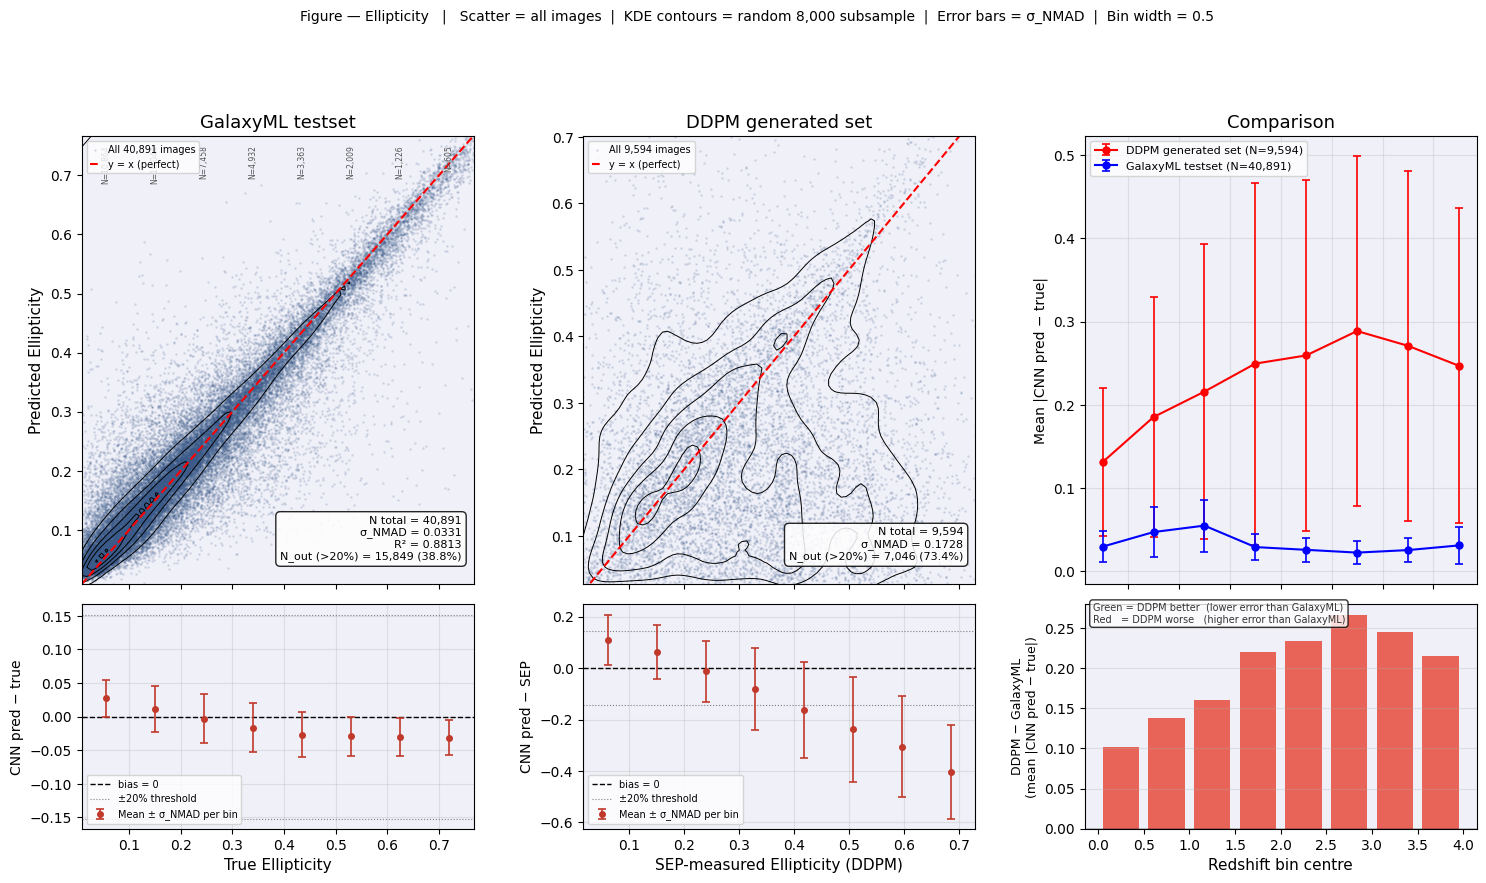

Saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/eval_combined_ellipticity.png



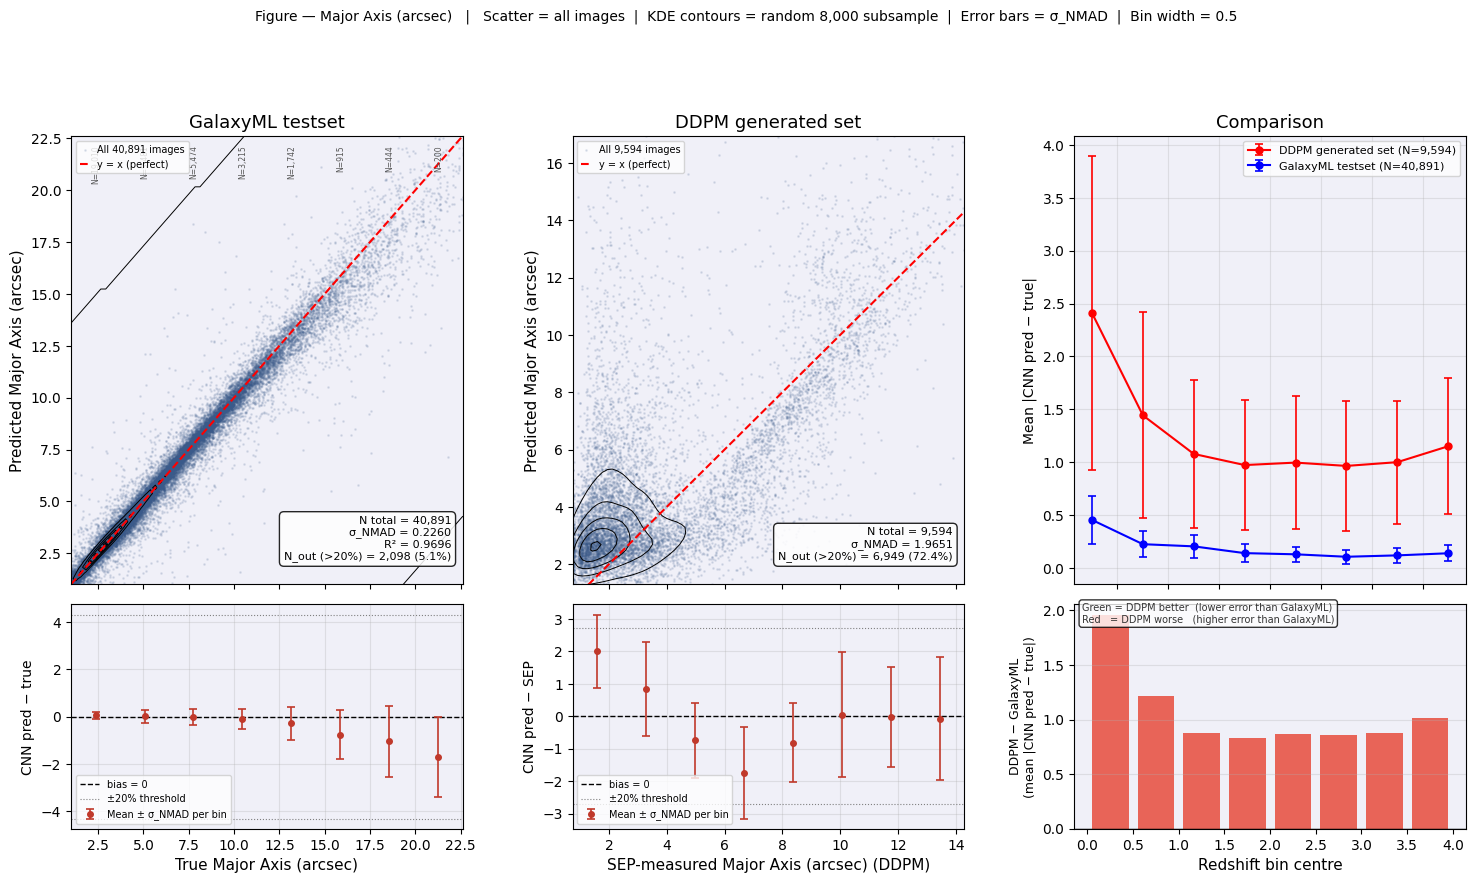

Saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/eval_combined_major_axis.png



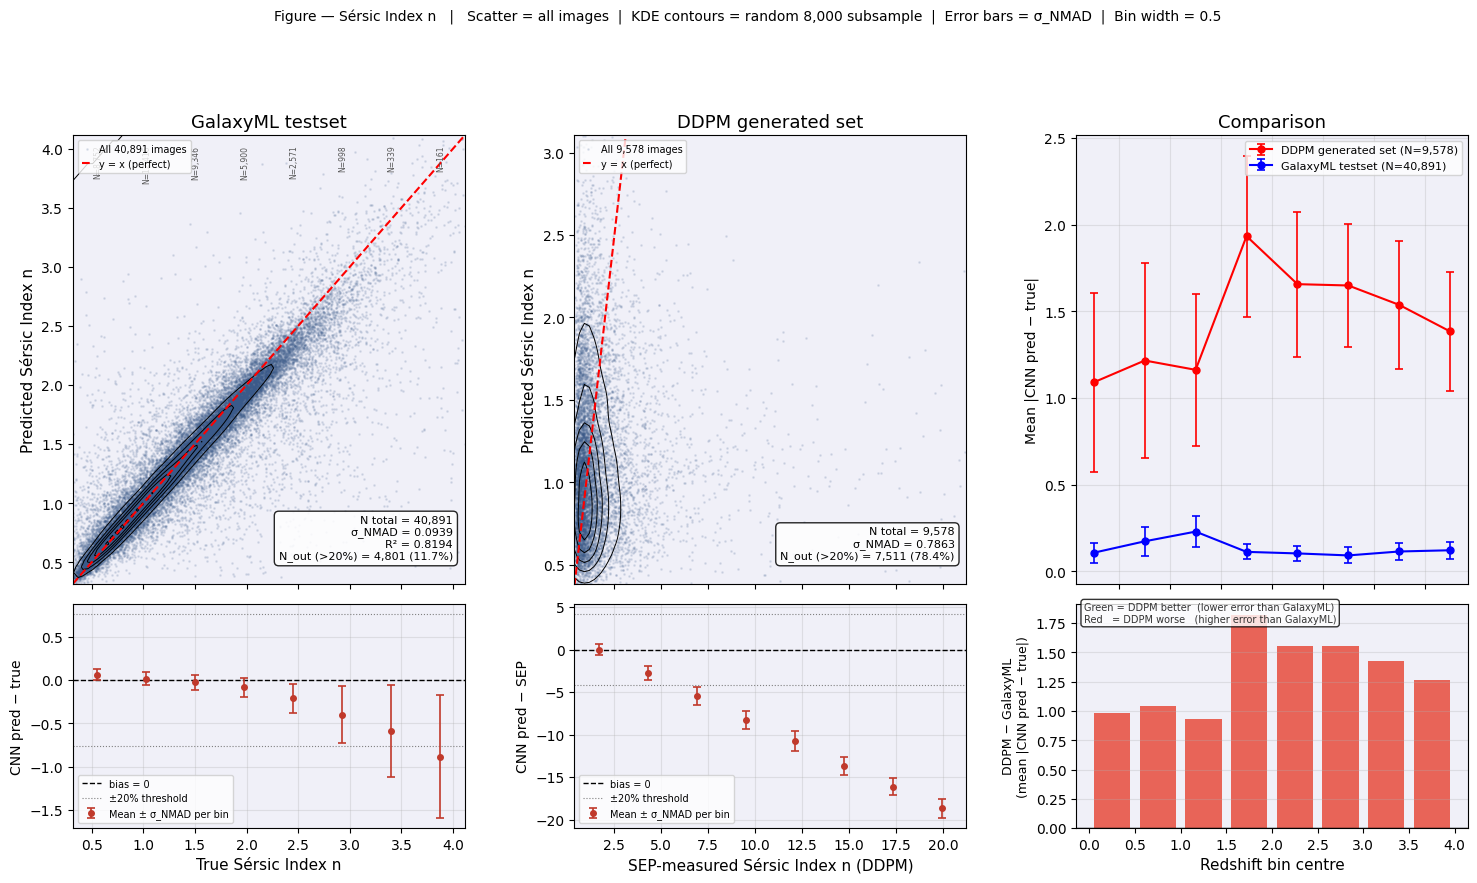

Saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/eval_combined_sersic_index.png



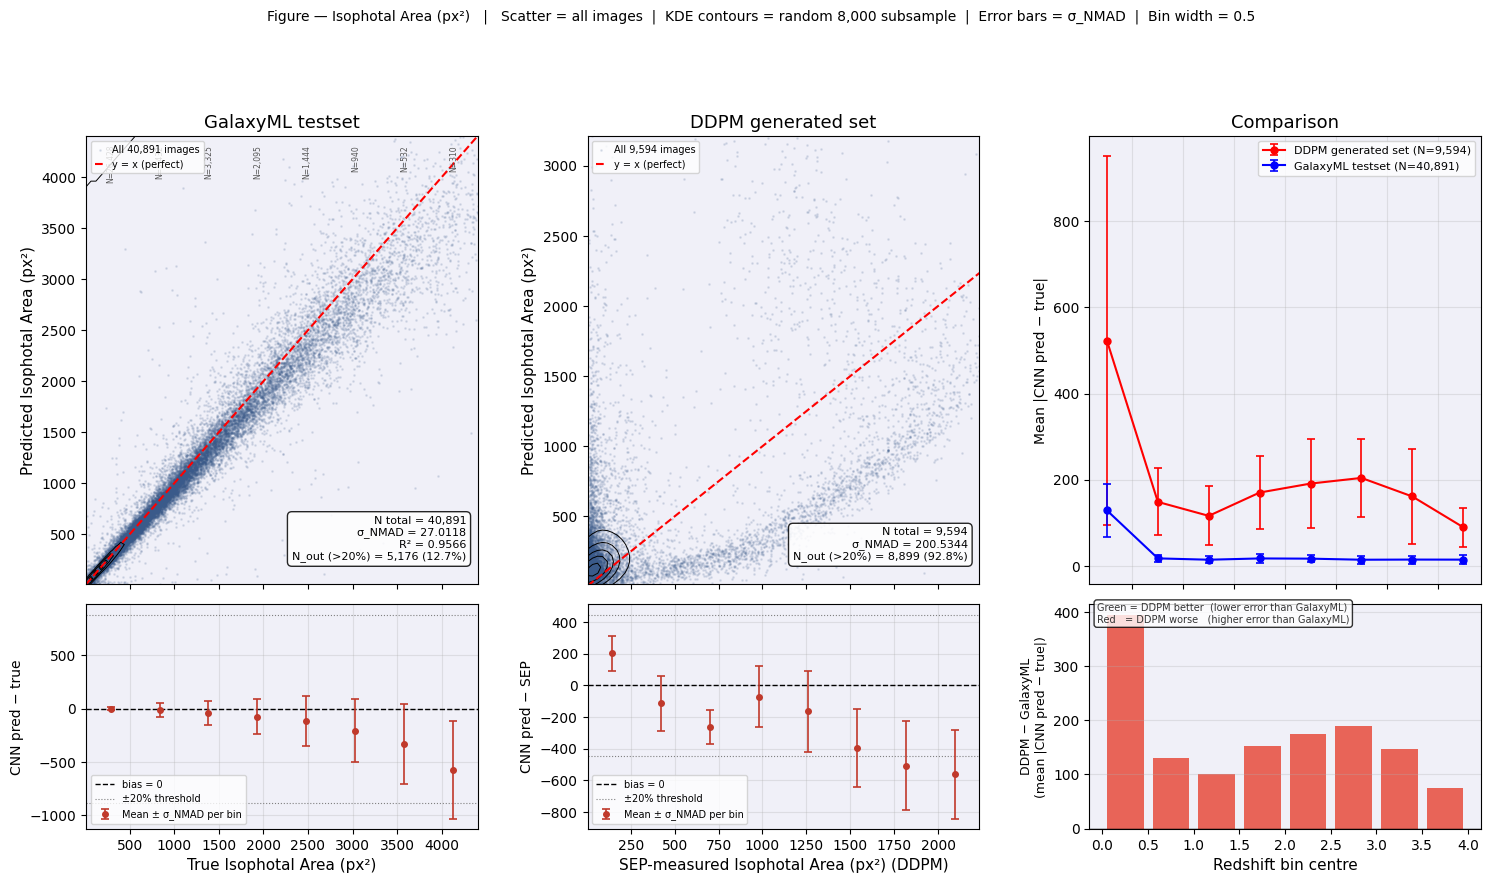

Saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/eval_combined_isophotal_area.png



In [12]:
import h5py
import pandas as pd

SEP_GEN  = "/Users/wen/Desktop/project/lizarraga_2024-main/Metrics/generated_images_metrics_wy.csv"
sep_df   = pd.read_csv(SEP_GEN)
sep_df["idx"] = sep_df["Image File"].str.extract(r"(\d+)\.pt$").astype(int)

SEP_COLS = {
    "g_ellipticity"   : "Ellipticity",
    "g_major_axis"    : "Semi-major Axis",
    "g_sersic_index"  : "Sersic Index",
    "g_isophotal_area": "Isophotal Area",
}

gen_preds_all = np.load(os.path.join(HERE, "gen_preds.npy"))

HDF5_TEST = "/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5"
test_idx  = np.load(os.path.join(HERE, "indices_test.npy"))
with h5py.File(HDF5_TEST, "r") as f:
    gt_z = f["specz_redshift"][test_idx]

ddpm_z = np.load(os.path.join(GEN_DIR, "generated_redshifts.npy"))

Z_BINS    = np.arange(0, 4.1, 0.5)
Z_CENTRES = 0.5 * (Z_BINS[:-1] + Z_BINS[1:])

def z_bin_abs_error(z_ref, abs_err):
    """Mean |error| ± σ_NMAD per z-bin — mirrors the redshift figure right column."""
    means, errs, ns = [], [], []
    for lo, hi in zip(Z_BINS[:-1], Z_BINS[1:]):
        m = (z_ref >= lo) & (z_ref < hi)
        if m.sum() > 1:
            means.append(np.mean(abs_err[m]))
            errs.append(sigma_nmad(abs_err[m]))
            ns.append(int(m.sum()))
        else:
            means.append(np.nan); errs.append(np.nan); ns.append(0)
    return np.array(means), np.array(errs), ns

print(f"SEP measurements: {len(sep_df):,} / 10,000 generated images")
print(f"GT redshifts: {len(gt_z):,}  DDPM redshifts: {len(ddpm_z):,}")

KDE_SUBSAMPLE = 8000
rng = np.random.default_rng(42)
from sklearn.metrics import r2_score

for i, (col, label, short) in enumerate(zip(TARGET_COLS, PARAM_LABELS, PARAM_SHORT)):
    gt_pred = test_preds[:, i]
    gt_true = test_true[:, i]
    res     = gt_pred - gt_true
    vlo, vhi = np.percentile(gt_true, 0.5), np.percentile(gt_true, 99.5)
    morph_bins = np.linspace(vlo, vhi, 9)
    bx, bmean, bnmad, bcounts = bin_stats(gt_true, res, morph_bins)

    sep_col        = SEP_COLS[col]
    valid          = sep_df.dropna(subset=[sep_col])
    ddpm_idx       = valid["idx"].values
    ddpm_sep       = valid[sep_col].values.astype(np.float32)
    ddpm_cnn       = gen_preds_all[ddpm_idx, i]
    ddpm_z_matched = ddpm_z[ddpm_idx]
    ddpm_res       = ddpm_cnn - ddpm_sep

    dlo  = np.percentile(ddpm_sep, 0.5);  dhi  = np.percentile(ddpm_sep, 99.5)
    dplo = np.percentile(ddpm_cnn, 0.5);  dphi = np.percentile(ddpm_cnn, 99.5)

    # ── right-column: mean |error| per z-bin (mirrors redshift figure) ───
    gt_ae_m,   gt_ae_e,   _ = z_bin_abs_error(gt_z,          np.abs(res))
    ddpm_ae_m, ddpm_ae_e, _ = z_bin_abs_error(ddpm_z_matched, np.abs(ddpm_res))

    # KDE — GT scatter
    idx_kde = rng.choice(len(gt_true), KDE_SUBSAMPLE, replace=False)
    xy  = np.vstack([gt_true[idx_kde], gt_pred[idx_kde]])
    kde = gaussian_kde(xy, bw_method=0.15)
    xg, yg = np.mgrid[vlo:vhi:80j, vlo:vhi:80j]
    zg = kde(np.vstack([xg.ravel(), yg.ravel()])).reshape(80, 80)

    # KDE — DDPM scatter
    n_kde2 = min(KDE_SUBSAMPLE, len(ddpm_sep))
    idx_k2 = rng.choice(len(ddpm_sep), n_kde2, replace=False)
    xy2    = np.vstack([ddpm_sep[idx_k2], ddpm_cnn[idx_k2]])
    kde2   = gaussian_kde(xy2, bw_method=0.15)
    xg2, yg2 = np.mgrid[dlo:dhi:80j, dplo:dphi:80j]
    zg2 = kde2(np.vstack([xg2.ravel(), yg2.ravel()])).reshape(80, 80)

    fig, axes = plt.subplots(
        2, 3, figsize=(18, 9),
        gridspec_kw={"height_ratios": [3, 1.5], "hspace": 0.06, "wspace": 0.28}
    )
    fig.suptitle(
        f"Figure — {label}   |   "
        f"Scatter = all images  |  KDE contours = random {KDE_SUBSAMPLE:,} subsample  |  "
        f"Error bars = σ_NMAD  |  Bin width = 0.5",
        fontsize=10, y=1.02
    )
    ax_s_gt  = axes[0, 0];  ax_r_gt   = axes[1, 0]
    ax_s_ddpm = axes[0, 1]; ax_r_ddpm = axes[1, 1]
    ax_comp   = axes[0, 2]; ax_diff   = axes[1, 2]

    # ── upper-left: GalaxyML testset scatter ──────────────────────────────
    ax_s_gt.set_facecolor("#f0f0f8")
    ax_s_gt.scatter(gt_true, gt_pred, s=1, alpha=0.12, color="#3a5a8a", rasterized=True,
                    label=f"All {len(gt_true):,} images")
    ax_s_gt.contour(xg, yg, zg, levels=5, colors="black", linewidths=0.7)
    ax_s_gt.plot([vlo, vhi], [vlo, vhi], "r--", lw=1.5, label="y = x (perfect)")
    ax_s_gt.set_xlim(vlo, vhi); ax_s_gt.set_ylim(vlo, vhi)
    ax_s_gt.set_ylabel(f"Predicted {label}", fontsize=11)
    ax_s_gt.set_title("GalaxyML testset", fontsize=13)
    ax_s_gt.set_xticklabels([])
    ax_s_gt.legend(fontsize=7, loc="upper left", handlelength=1)
    r2     = r2_score(gt_true, gt_pred)
    nmad_g = sigma_nmad(res)
    n_out  = np.sum(np.abs(res) / (np.abs(gt_true) + 1e-8) > 0.20)
    ax_s_gt.text(0.97, 0.05,
                 f"N total = {len(gt_true):,}\nσ_NMAD = {nmad_g:.4f}\n"
                 f"R² = {r2:.4f}\nN_out (>20%) = {n_out:,} ({100*n_out/len(gt_true):.1f}%)",
                 transform=ax_s_gt.transAxes, fontsize=8, va="bottom", ha="right",
                 bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85))
    for xc, cnt in zip(bx, bcounts):
        ax_s_gt.text(xc, vhi*0.98, f"N={cnt:,}", ha="center", va="top",
                     fontsize=5.5, color="#555", rotation=90)

    # ── upper-middle: DDPM generated set scatter ──────────────────────────
    ax_s_ddpm.set_facecolor("#f0f0f8")
    ax_s_ddpm.scatter(ddpm_sep, ddpm_cnn, s=1, alpha=0.12, color="#3a5a8a", rasterized=True,
                      label=f"All {len(ddpm_sep):,} images")
    ax_s_ddpm.contour(xg2, yg2, zg2, levels=5, colors="black", linewidths=0.7)
    ax_s_ddpm.plot([dlo, dhi], [dlo, dhi], "r--", lw=1.5, label="y = x (perfect)")
    ax_s_ddpm.set_xlim(dlo, dhi); ax_s_ddpm.set_ylim(dplo, dphi)
    ax_s_ddpm.set_ylabel(f"Predicted {label}", fontsize=11)
    ax_s_ddpm.set_title("DDPM generated set", fontsize=13)
    ax_s_ddpm.set_xticklabels([])
    ax_s_ddpm.legend(fontsize=7, loc="upper left", handlelength=1)
    ddpm_nmad  = sigma_nmad(ddpm_res)
    n_out_ddpm = np.sum(np.abs(ddpm_res) / (np.abs(ddpm_sep) + 1e-8) > 0.20)
    ax_s_ddpm.text(0.97, 0.05,
                   f"N total = {len(ddpm_sep):,}\nσ_NMAD = {ddpm_nmad:.4f}\n"
                   f"N_out (>20%) = {n_out_ddpm:,} ({100*n_out_ddpm/len(ddpm_sep):.1f}%)",
                   transform=ax_s_ddpm.transAxes, fontsize=8, va="bottom", ha="right",
                   bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85))

    # ── upper-right: mean |error| per z-bin — GT vs DDPM ─────────────────
    ax_comp.set_facecolor("#f0f0f8")
    ax_comp.errorbar(Z_CENTRES, ddpm_ae_m, yerr=ddpm_ae_e, fmt="ro-",
                     capsize=3, capthick=1.2, elinewidth=1.2, markersize=5,
                     label=f"DDPM generated set (N={len(ddpm_z_matched):,})")
    ax_comp.errorbar(Z_CENTRES, gt_ae_m, yerr=gt_ae_e, fmt="bo-",
                     capsize=3, capthick=1.2, elinewidth=1.2, markersize=5,
                     label=f"GalaxyML testset (N={len(gt_z):,})")
    ax_comp.set_ylabel(f"Mean |CNN pred − true|", fontsize=10)
    ax_comp.set_title("Comparison", fontsize=13)
    ax_comp.legend(fontsize=8); ax_comp.grid(True, alpha=0.3)
    ax_comp.set_xticklabels([])

    # ── lower-left: GalaxyML testset bias per morph bin ───────────────────
    ax_r_gt.set_facecolor("#f0f0f8")
    ax_r_gt.axhline(0, color="black", lw=1, ls="--", label="bias = 0")
    ax_r_gt.axhline( 0.2*(vhi-vlo), color="gray", lw=0.8, ls=":")
    ax_r_gt.axhline(-0.2*(vhi-vlo), color="gray", lw=0.8, ls=":", label="±20% threshold")
    ax_r_gt.errorbar(bx, bmean, yerr=bnmad, fmt="o", color="#c0392b",
                     capsize=3, capthick=1.2, elinewidth=1.2, markersize=4,
                     label="Mean ± σ_NMAD per bin")
    ax_r_gt.set_xlim(vlo, vhi)
    ax_r_gt.set_xlabel(f"True {label}", fontsize=11)
    ax_r_gt.set_ylabel("CNN pred − true", fontsize=10)
    ax_r_gt.legend(fontsize=7, loc="lower left"); ax_r_gt.grid(True, alpha=0.3)

    # ── lower-middle: DDPM bias per morph bin (SEP true) ──────────────────
    bx_d, bm_d, bn_d, _ = bin_stats(ddpm_sep, ddpm_res, np.linspace(dlo, dhi, 9))
    ax_r_ddpm.set_facecolor("#f0f0f8")
    ax_r_ddpm.axhline(0, color="black", lw=1, ls="--", label="bias = 0")
    ax_r_ddpm.axhline( 0.2*(dhi-dlo), color="gray", lw=0.8, ls=":")
    ax_r_ddpm.axhline(-0.2*(dhi-dlo), color="gray", lw=0.8, ls=":", label="±20% threshold")
    ax_r_ddpm.errorbar(bx_d, bm_d, yerr=bn_d, fmt="o", color="#c0392b",
                       capsize=3, capthick=1.2, elinewidth=1.2, markersize=4,
                       label="Mean ± σ_NMAD per bin")
    ax_r_ddpm.set_xlim(dlo, dhi)
    ax_r_ddpm.set_xlabel(f"SEP-measured {label} (DDPM)", fontsize=11)
    ax_r_ddpm.set_ylabel("CNN pred − SEP", fontsize=10)
    ax_r_ddpm.legend(fontsize=7, loc="lower left"); ax_r_ddpm.grid(True, alpha=0.3)

    # ── lower-right: DDPM − GT mean|error| per z-bin (green/red) ─────────
    diff   = ddpm_ae_m - gt_ae_m
    colors = ["#2ecc71" if d < 0 else "#e74c3c" for d in np.nan_to_num(diff)]
    ax_diff.set_facecolor("#f0f0f8")
    ax_diff.bar(Z_CENTRES, diff, width=0.4, color=colors, alpha=0.85)
    ax_diff.axhline(0, color="black", lw=1)
    ax_diff.set_xlabel("Redshift bin centre", fontsize=11)
    ax_diff.set_ylabel(f"DDPM − GalaxyML\n(mean |CNN pred − true|)", fontsize=9)
    ax_diff.text(0.02, 0.92,
                 "Green = DDPM better  (lower error than GalaxyML)\nRed   = DDPM worse   (higher error than GalaxyML)",
                 transform=ax_diff.transAxes, fontsize=7, color="#333",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax_diff.grid(True, alpha=0.3, axis="y")

    out_path = os.path.join(HERE, f"eval_combined_{short}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}\n")

## 6.5 Domain Shift Diagnosis — Pixel Distribution Comparison

Compare pixel value distributions between GalaxyML test images and DDPM generated images, **before and after preprocessing** (asinh + channel standardisation).

- If distributions look similar after preprocessing → domain shift is NOT the main problem
- If distributions look very different → the CNN is seeing out-of-distribution inputs, which explains the poor DDPM performance

RAW pixel statistics (before preprocessing):
             GT mean     GT std     GT p99  |   DDPM mean   DDPM std   DDPM p99
  g-band       0.192      0.922      3.198  |       0.106      0.398      1.659
  r-band       0.406      1.853      6.536  |       0.204      0.721      3.077
  i-band       0.610      2.858      9.753  |       0.303      1.171      4.641
  z-band       0.792      3.667     12.575  |       0.381      1.415      5.791
  y-band       0.947      4.330     14.655  |       0.448      1.634      6.641

PREPROCESSED pixel statistics (asinh + standardised — what CNN sees):
             GT mean     GT std  |   DDPM mean   DDPM std
  g-band      -0.032      0.972  |      -0.152      0.666
  r-band      -0.037      0.969  |      -0.190      0.677
  i-band      -0.038      0.966  |      -0.202      0.701
  z-band      -0.037      0.970  |      -0.211      0.711
  y-band      -0.035      0.974  |      -0.218      0.729


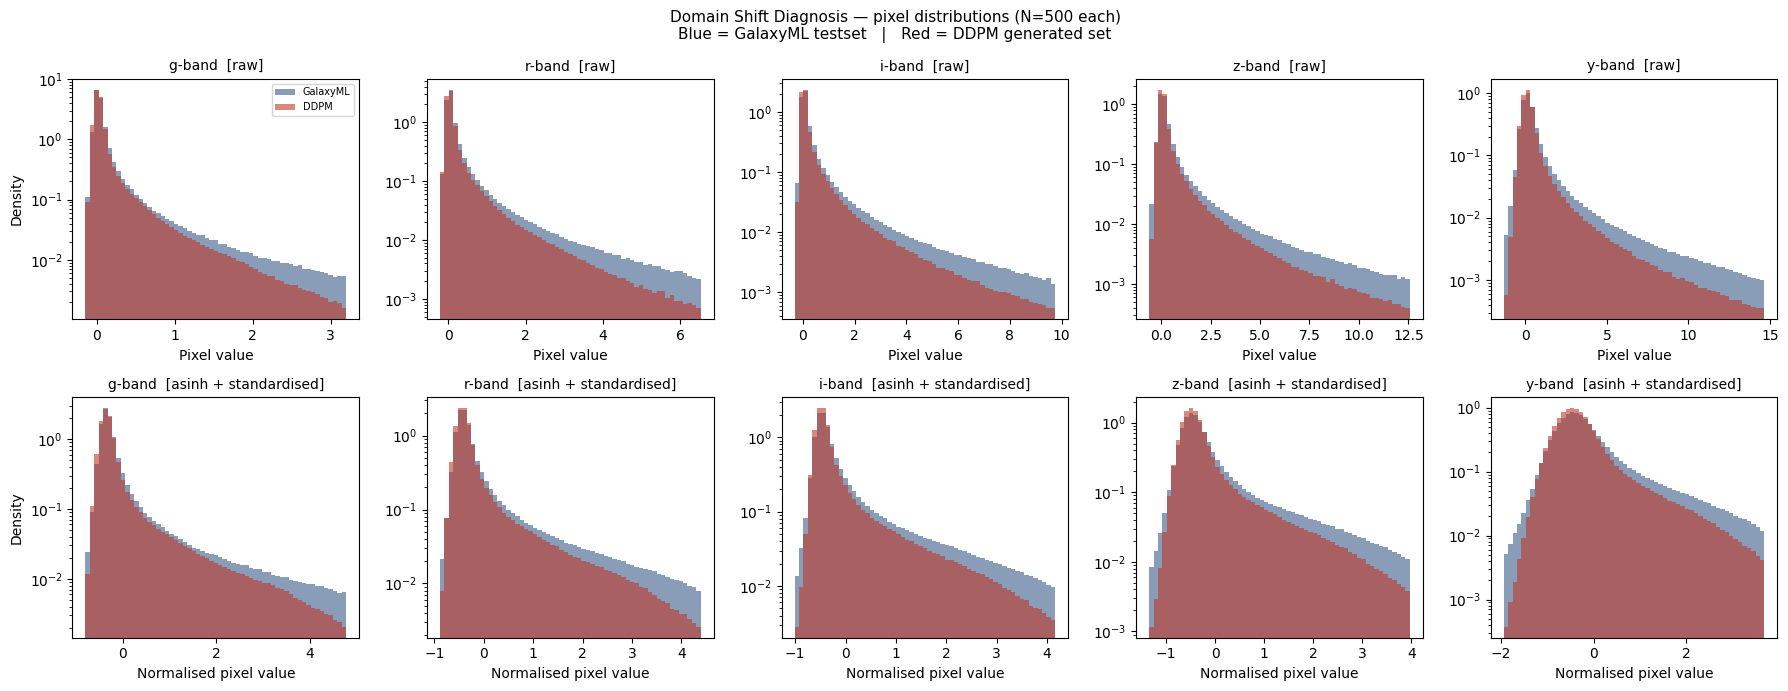

Saved domain_shift_diagnosis.png

Interpretation:
  Top row (raw):   large difference → DDPM generates different pixel intensities than HSC
  Bottom row (std): if still different after normalisation → CNN sees OOD inputs → explains poor DDPM results


In [13]:
import h5py

N_SAMPLE  = 500
BANDS     = ["g", "r", "i", "z", "y"]
HDF5_TEST = "/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5"

rng_d = np.random.default_rng(0)

# ── sample GalaxyML test images ───────────────────────────────────────────
test_idx_all = np.load(os.path.join(HERE, "indices_test.npy"))
chosen_gt    = np.sort(rng_d.choice(test_idx_all, N_SAMPLE, replace=False))
with h5py.File(HDF5_TEST, "r") as f:
    gt_imgs = f["image"][chosen_gt].astype(np.float32)   # (N, 5, 64, 64)

# ── sample DDPM generated images ─────────────────────────────────────────
pt_files_all = sorted(f for f in os.listdir(GEN_DIR) if f.endswith(".pt"))
chosen_ddpm  = rng_d.choice(len(pt_files_all), N_SAMPLE, replace=False)
ddpm_imgs    = np.stack([
    torch.load(os.path.join(GEN_DIR, pt_files_all[j]),
               map_location="cpu", weights_only=True).numpy()
    for j in chosen_ddpm
])  # (N, 5, 64, 64)

IMG_MEAN_np = np.array(img_stats["mean"], dtype=np.float32).reshape(1, 5, 1, 1)
IMG_STD_np  = np.array(img_stats["std"],  dtype=np.float32).reshape(1, 5, 1, 1)

# preprocessed versions
gt_proc   = (np.arcsinh(gt_imgs)   - IMG_MEAN_np) / IMG_STD_np
ddpm_proc = (np.arcsinh(ddpm_imgs) - IMG_MEAN_np) / IMG_STD_np

# ── print summary stats ──────────────────────────────────────────────────
print("RAW pixel statistics (before preprocessing):")
print(f"  {'':6}  {'GT mean':>10} {'GT std':>10} {'GT p99':>10}  |  "
      f"{'DDPM mean':>10} {'DDPM std':>10} {'DDPM p99':>10}")
for b, band in enumerate(BANDS):
    g = gt_imgs[:, b].ravel()
    d = ddpm_imgs[:, b].ravel()
    print(f"  {band}-band  {g.mean():>10.3f} {g.std():>10.3f} {np.percentile(g,99):>10.3f}  |  "
          f"{d.mean():>10.3f} {d.std():>10.3f} {np.percentile(d,99):>10.3f}")

print("\nPREPROCESSED pixel statistics (asinh + standardised — what CNN sees):")
print(f"  {'':6}  {'GT mean':>10} {'GT std':>10}  |  {'DDPM mean':>10} {'DDPM std':>10}")
for b, band in enumerate(BANDS):
    g = gt_proc[:, b].ravel()
    d = ddpm_proc[:, b].ravel()
    print(f"  {band}-band  {g.mean():>10.3f} {g.std():>10.3f}  |  {d.mean():>10.3f} {d.std():>10.3f}")

# ── plot: raw vs preprocessed, per band ──────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle(
    f"Domain Shift Diagnosis — pixel distributions (N={N_SAMPLE} each)\n"
    "Blue = GalaxyML testset   |   Red = DDPM generated set",
    fontsize=11
)

for b, band in enumerate(BANDS):
    # top row: raw
    ax = axes[0, b]
    g_raw = gt_imgs[:, b].ravel()
    d_raw = ddpm_imgs[:, b].ravel()
    lo = min(np.percentile(g_raw, 0.1), np.percentile(d_raw, 0.1))
    hi = max(np.percentile(g_raw, 99),  np.percentile(d_raw, 99))
    bins = np.linspace(lo, hi, 60)
    ax.hist(g_raw, bins=bins, density=True, alpha=0.6, color="#3a5a8a", label="GalaxyML")
    ax.hist(d_raw, bins=bins, density=True, alpha=0.6, color="#c0392b", label="DDPM")
    ax.set_title(f"{band}-band  [raw]", fontsize=10)
    ax.set_xlabel("Pixel value"); ax.set_ylabel("Density" if b == 0 else "")
    if b == 0: ax.legend(fontsize=7)
    ax.set_yscale("log")

    # bottom row: preprocessed
    ax2 = axes[1, b]
    g_p = gt_proc[:, b].ravel()
    d_p = ddpm_proc[:, b].ravel()
    lo2 = min(np.percentile(g_p, 0.1), np.percentile(d_p, 0.1))
    hi2 = max(np.percentile(g_p, 99),  np.percentile(d_p, 99))
    bins2 = np.linspace(lo2, hi2, 60)
    ax2.hist(g_p, bins=bins2, density=True, alpha=0.6, color="#3a5a8a", label="GalaxyML")
    ax2.hist(d_p, bins=bins2, density=True, alpha=0.6, color="#c0392b", label="DDPM")
    ax2.set_title(f"{band}-band  [asinh + standardised]", fontsize=10)
    ax2.set_xlabel("Normalised pixel value"); ax2.set_ylabel("Density" if b == 0 else "")
    ax2.set_yscale("log")

plt.tight_layout()
plt.savefig(os.path.join(HERE, "domain_shift_diagnosis.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved domain_shift_diagnosis.png")
print()
print("Interpretation:")
print("  Top row (raw):   large difference → DDPM generates different pixel intensities than HSC")
print("  Bottom row (std): if still different after normalisation → CNN sees OOD inputs → explains poor DDPM results")

## 6.6 Fix: Domain-specific Normalisation for DDPM Images

The DDPM training data uses different physical units from the HDF5 archive, so `denormalize_images()` cannot bridge the gap.

The correct fix is **domain-specific normalisation**: instead of using HDF5-derived image stats (mean/std) to preprocess DDPM images, we compute per-channel arcsinh mean/std *from the DDPM population itself* and apply those when feeding DDPM images into the CNN.

This ensures the CNN receives zero-mean, unit-variance inputs for both domains — the same contract it was trained on.

In [14]:
import sys, os, json, time
import numpy as np
import torch
sys.path.insert(0, HERE)
from model import MorphCNN

DDPM_STATS_FILE = os.path.join(HERE, "ddpm_image_stats.json")

# ── Step 1: compute per-channel arcsinh statistics from DDPM images ────────
if os.path.exists(DDPM_STATS_FILE):
    with open(DDPM_STATS_FILE) as fp:
        ddpm_stats = json.load(fp)
    print(f"Loaded {DDPM_STATS_FILE}")
else:
    print("Computing DDPM image statistics (all 10,000 images)...")
    pt_files_all = sorted(f for f in os.listdir(GEN_DIR) if f.endswith(".pt"))
    
    # accumulate per-channel arcsinh values in chunks to save RAM
    BATCH = 500
    sum1  = np.zeros(5, dtype=np.float64)
    sum2  = np.zeros(5, dtype=np.float64)
    n_pix = 0
    
    for s in range(0, len(pt_files_all), BATCH):
        chunk = np.stack([
            torch.load(os.path.join(GEN_DIR, pt_files_all[j]),
                       map_location="cpu", weights_only=True).numpy()
            for j in range(s, min(s + BATCH, len(pt_files_all)))
        ])  # (B, 5, 64, 64)
        chunk = np.arcsinh(chunk)
        sum1  += chunk.mean(axis=(0, 2, 3))   # per-channel mean over images
        sum2  += (chunk ** 2).mean(axis=(0, 2, 3))
        n_pix += 1
        print(f"  {min(s+BATCH, len(pt_files_all)):>5,}/{len(pt_files_all)}", end="\r")
    
    mean = (sum1 / n_pix).tolist()
    std  = np.sqrt(sum2 / n_pix - (sum1 / n_pix) ** 2).tolist()
    ddpm_stats = {"mean": mean, "std": std}
    with open(DDPM_STATS_FILE, "w") as fp:
        json.dump(ddpm_stats, fp, indent=2)
    print(f"\nSaved {DDPM_STATS_FILE}")

# ── Compare HDF5 stats vs DDPM stats ──────────────────────────────────────
print("\n  Channel  HDF5 mean  HDF5 std  |  DDPM mean  DDPM std")
print("  " + "-"*55)
for b, band in enumerate(["g","r","i","z","y"]):
    print(f"  {band}-band   {img_stats['mean'][b]:>9.3f}  {img_stats['std'][b]:>8.3f}  |  "
          f"{ddpm_stats['mean'][b]:>9.3f}  {ddpm_stats['std'][b]:>8.3f}")

Computing DDPM image statistics (all 10,000 images)...
  10,000/10000
Saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/ddpm_image_stats.json

  Channel  HDF5 mean  HDF5 std  |  DDPM mean  DDPM std
  -------------------------------------------------------
  g-band       0.144     0.363  |      0.085     0.238
  r-band       0.253     0.529  |      0.147     0.352
  i-band       0.330     0.635  |      0.196     0.439
  z-band       0.392     0.715  |      0.234     0.502
  y-band       0.445     0.796  |      0.265     0.576


In [15]:
# ── Step 2: re-run inference with DDPM-specific normalisation ─────────────
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

model = MorphCNN(n_outputs=4).to(DEVICE)
ckpt  = torch.load(os.path.join(HERE, "checkpoints", "best.pt"),
                   map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model"])
model.eval()

pt_files_all = sorted(f for f in os.listdir(GEN_DIR) if f.endswith(".pt"))

DDPM_MEAN = torch.tensor(ddpm_stats["mean"], dtype=torch.float32).view(5,1,1)
DDPM_STD  = torch.tensor(ddpm_stats["std"],  dtype=torch.float32).view(5,1,1)

def denormalise(arr):
    out = []
    for i, col in enumerate(TARGET_COLS):
        v = arr[:, i].copy()
        v = v * NORM[col]["std"] + NORM[col]["mean"]
        t = NORM[col]["transform"]
        if t == "log1p": v = np.expm1(v)
        elif t == "log":  v = np.exp(v)
        out.append(v)
    return np.stack(out, axis=1)

BATCH = 256
gen_preds_fixed_norm = []

print("Re-running inference with DDPM-specific normalisation...")
for s in range(0, len(pt_files_all), BATCH):
    batch_files = pt_files_all[s : s + BATCH]
    imgs = torch.stack([
        torch.load(os.path.join(GEN_DIR, fn), map_location="cpu", weights_only=True)
        for fn in batch_files
    ])
    # use DDPM-specific stats instead of HDF5 stats
    imgs = (torch.arcsinh(imgs) - DDPM_MEAN) / DDPM_STD
    with torch.no_grad():
        gen_preds_fixed_norm.append(model(imgs.to(DEVICE)).cpu().numpy())
    if s % (BATCH * 5) == 0:
        print(f"  {s + len(batch_files):>5,}/{len(pt_files_all)}", end="\r")

gen_preds_fixed_norm = np.concatenate(gen_preds_fixed_norm)
gen_preds_fixed      = denormalise(gen_preds_fixed_norm)

print(f"\nDone. shape: {gen_preds_fixed.shape}")

# ── Save as separate file (keep original gen_preds.npy untouched) ──────────
np.save(os.path.join(HERE, "gen_preds_domain_norm.npy"), gen_preds_fixed)
print("Saved gen_preds_domain_norm.npy")

# quick sanity: compare σ_NMAD for original vs fixed (using SEP as proxy)
import pandas as pd
sep_df_tmp = pd.read_csv("/Users/wen/Desktop/project/lizarraga_2024-main/Metrics/generated_images_metrics_wy.csv")
sep_df_tmp["idx"] = sep_df_tmp["Image File"].str.extract(r"(\d+)\.pt$").astype(int)

SEP_COLS = {
    "g_ellipticity"   : "Ellipticity",
    "g_major_axis"    : "Semi-major Axis",
    "g_sersic_index"  : "Sersic Index",
    "g_isophotal_area": "Isophotal Area",
}

print(f"\n{'Parameter':<20} {'σ_NMAD (HDF5 norm)':>20} {'σ_NMAD (DDPM norm)':>20}")
print("-" * 62)
for j, col in enumerate(TARGET_COLS):
    valid      = sep_df_tmp.dropna(subset=[SEP_COLS[col]])
    idx        = valid["idx"].values
    sep_vals   = valid[SEP_COLS[col]].values.astype(np.float32)
    
    old_res = gen_preds_all[idx, j] - sep_vals
    new_res = gen_preds_fixed[idx, j] - sep_vals
    
    def s_nmad(r): return 1.4826 * np.median(np.abs(r - np.median(r)))
    print(f"  {col:<18} {s_nmad(old_res):>20.4f} {s_nmad(new_res):>20.4f}")

Re-running inference with DDPM-specific normalisation...
  9,216/10000
Done. shape: (10000, 4)
Saved gen_preds_domain_norm.npy

Parameter              σ_NMAD (HDF5 norm)   σ_NMAD (DDPM norm)
--------------------------------------------------------------
  g_ellipticity                    0.1728               0.1715
  g_major_axis                     1.9651               2.0747
  g_sersic_index                   0.7863               0.8738
  g_isophotal_area               200.5344             201.0871


## 6.7 Structural Difference Evidence

### Method 1 — CNN Feature Space (t-SNE)

Extract 256-dim feature vectors from the CNN encoder (global-avg-pool layer, before the FC head) for real and DDPM images, then project to 2D with t-SNE.

**If the two clouds separate clearly → the CNN sees them as structurally different distributions**, which directly explains why morphology predictions fail on DDPM images even after normalisation correction.

### Method 2 — Azimuthally Averaged Radial Brightness Profile

Average the i-band brightness as a function of radius from the galaxy centre for both datasets. A Sérsic galaxy has a characteristic exponential/power-law fall-off; deviations in DDPM profiles reveal structural differences.

Real features:  (1000, 256)
DDPM features:  (1000, 256)
Running t-SNE (~1 min)...
t-SNE done.


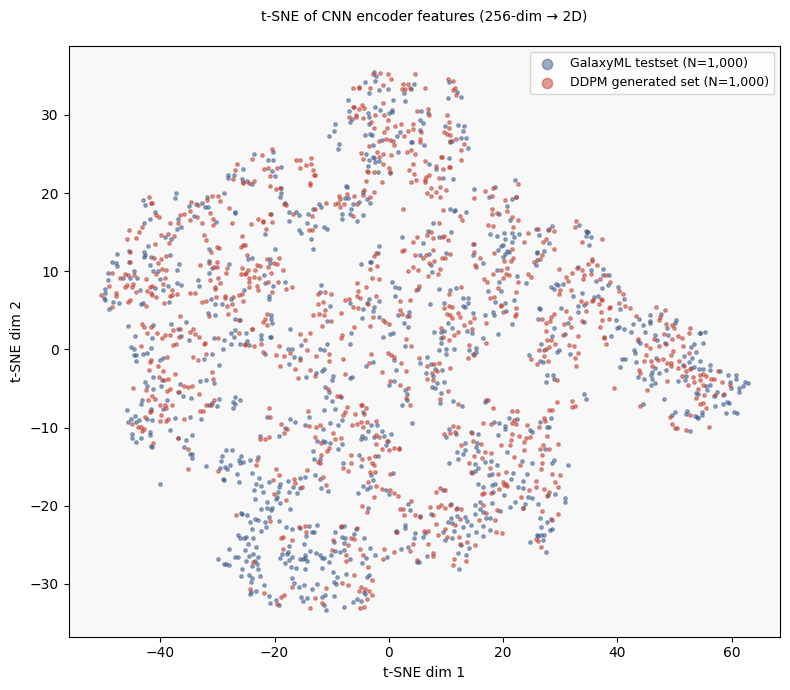

Saved tsne_features.png


In [16]:
import h5py
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sklearn

N_FEAT    = 1000   # samples per class for t-SNE
HDF5_TEST = "/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5"

# ── build a feature extractor (encoder + pool, no head) ───────────────────
import torch.nn as nn

class FeatureExtractor(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.encoder = full_model.encoder
        self.pool    = full_model.pool

    def forward(self, x):
        return self.pool(self.encoder(x)).squeeze(-1).squeeze(-1)   # (B, 256)

feat_model = FeatureExtractor(model).to(DEVICE)
feat_model.eval()

HDF5_MEAN = torch.tensor(img_stats["mean"], dtype=torch.float32).view(5,1,1)
HDF5_STD  = torch.tensor(img_stats["std"],  dtype=torch.float32).view(5,1,1)

# ── sample & extract features: real ───────────────────────────────────────
rng_f        = np.random.default_rng(7)
test_idx_all = np.load(os.path.join(HERE, "indices_test.npy"))
chosen_gt    = np.sort(rng_f.choice(test_idx_all, N_FEAT, replace=False))

feats_real = []
BATCH = 128
with h5py.File(HDF5_TEST, "r") as f:
    for s in range(0, N_FEAT, BATCH):
        ci   = chosen_gt[s:s+BATCH]
        imgs = torch.from_numpy(f["image"][ci].astype(np.float32))
        imgs = (torch.arcsinh(imgs) - HDF5_MEAN) / HDF5_STD
        with torch.no_grad():
            feats_real.append(feat_model(imgs.to(DEVICE)).cpu().numpy())
feats_real = np.concatenate(feats_real)
print(f"Real features:  {feats_real.shape}")

# ── sample & extract features: DDPM ───────────────────────────────────────
pt_files_all = sorted(f for f in os.listdir(GEN_DIR) if f.endswith(".pt"))
chosen_ddpm  = rng_f.choice(len(pt_files_all), N_FEAT, replace=False)

feats_ddpm = []
for s in range(0, N_FEAT, BATCH):
    batch_idx = chosen_ddpm[s:s+BATCH]
    imgs = torch.stack([
        torch.load(os.path.join(GEN_DIR, pt_files_all[j]),
                   map_location="cpu", weights_only=True)
        for j in batch_idx
    ])
    imgs = (torch.arcsinh(imgs) - HDF5_MEAN) / HDF5_STD
    with torch.no_grad():
        feats_ddpm.append(feat_model(imgs.to(DEVICE)).cpu().numpy())
feats_ddpm = np.concatenate(feats_ddpm)
print(f"DDPM features:  {feats_ddpm.shape}")

# ── t-SNE (n_iter renamed to max_iter in sklearn >= 1.2) ──────────────────
print("Running t-SNE (~1 min)...")
all_feats = np.vstack([feats_real, feats_ddpm])
labels    = np.array([0]*N_FEAT + [1]*N_FEAT)

sk_ver = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
tsne_kwargs = dict(n_components=2, perplexity=40, random_state=42, verbose=0)
tsne_kwargs["max_iter" if sk_ver >= (1, 2) else "n_iter"] = 1000

tsne  = TSNE(**tsne_kwargs)
embed = tsne.fit_transform(all_feats)
print("t-SNE done.")

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(embed[labels==0, 0], embed[labels==0, 1],
           s=6, alpha=0.5, color="#3a5a8a",
           label=f"GalaxyML testset (N={N_FEAT:,})", rasterized=True)
ax.scatter(embed[labels==1, 0], embed[labels==1, 1],
           s=6, alpha=0.5, color="#c0392b",
           label=f"DDPM generated set (N={N_FEAT:,})", rasterized=True)
ax.set_title("t-SNE of CNN encoder features (256-dim → 2D)\n",
             fontsize=10)    #  "Separation → CNN sees structural differences between the two domains"
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(fontsize=9, markerscale=3)
ax.set_facecolor("#f8f8f8")
plt.tight_layout()
plt.savefig(os.path.join(HERE, "tsne_features.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved tsne_features.png")

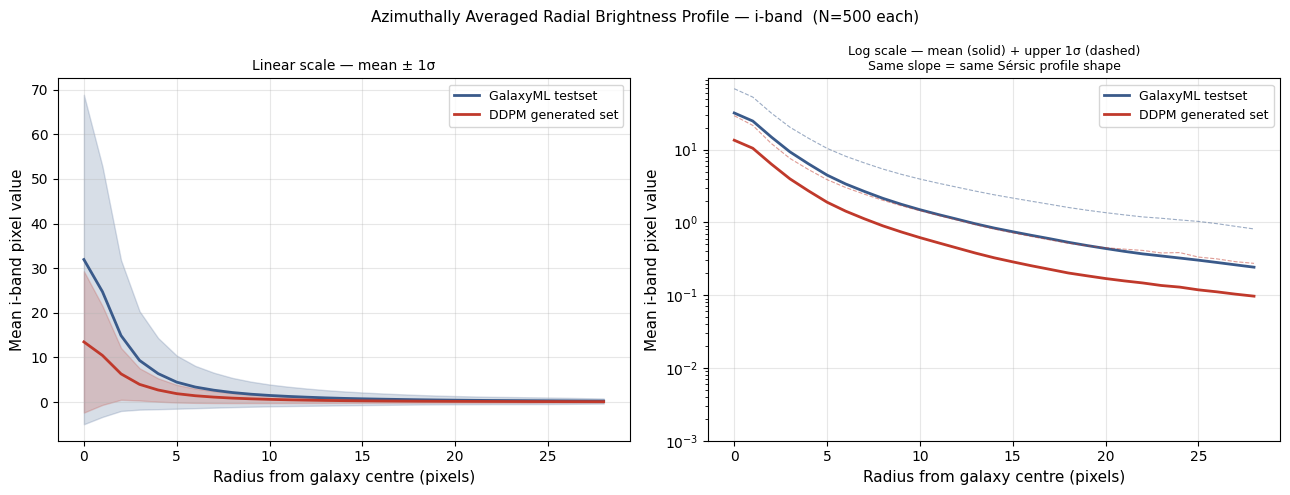

Saved radial_profile.png

DDPM / GalaxyML brightness ratio at key radii (i-band):
  r= 0 px: DDPM/real = 0.422
  r= 2 px: DDPM/real = 0.425
  r= 5 px: DDPM/real = 0.424
  r=10 px: DDPM/real = 0.413
  r=15 px: DDPM/real = 0.386
  r=20 px: DDPM/real = 0.387


In [17]:
# ── Method 2: Azimuthally Averaged Radial Profile ─────────────────────────
N_PROF   = 500
MAX_RAD  = 28
I_BAND   = 2     # i-band

rng_p = np.random.default_rng(99)

def radial_profile(image_2d):
    cy, cx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    y, x   = np.indices(image_2d.shape)
    r      = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    radii  = np.arange(0, MAX_RAD + 1)
    return np.array([image_2d[r == ri].mean() if (r == ri).any() else np.nan
                     for ri in radii])

# ── collect profiles: real ────────────────────────────────────────────────
chosen_gt_p = np.sort(rng_p.choice(test_idx_all, N_PROF, replace=False))
profiles_real = []
with h5py.File(HDF5_TEST, "r") as f:
    for idx in chosen_gt_p:
        profiles_real.append(radial_profile(f["image"][int(idx)][I_BAND]))
profiles_real = np.array(profiles_real)

pt_files_all = sorted(f for f in os.listdir(GEN_DIR) if f.endswith(".pt"))
chosen_ddpm_p = rng_p.choice(len(pt_files_all), N_PROF, replace=False)
profiles_ddpm = []
for j in chosen_ddpm_p:
    img = torch.load(os.path.join(GEN_DIR, pt_files_all[j]),
                     map_location="cpu", weights_only=True).numpy()[I_BAND]
    profiles_ddpm.append(radial_profile(img))
profiles_ddpm = np.array(profiles_ddpm)

radii  = np.arange(0, MAX_RAD + 1)
mean_r = np.nanmean(profiles_real, axis=0)
std_r  = np.nanstd(profiles_real,  axis=0)
mean_d = np.nanmean(profiles_ddpm, axis=0)
std_d  = np.nanstd(profiles_ddpm,  axis=0)

# ── plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Azimuthally Averaged Radial Brightness Profile — i-band  (N={N_PROF} each)",
             fontsize=11)

# ── left: linear scale with shaded ±1σ band ───────────────────────────────
ax = axes[0]
ax.plot(radii, mean_r, color="#3a5a8a", lw=2, label="GalaxyML testset")
ax.fill_between(radii, mean_r - std_r, mean_r + std_r, color="#3a5a8a", alpha=0.2)
ax.plot(radii, mean_d, color="#c0392b", lw=2, label="DDPM generated set")
ax.fill_between(radii, mean_d - std_d, mean_d + std_d, color="#c0392b", alpha=0.2)
ax.set_xlabel("Radius from galaxy centre (pixels)", fontsize=11)
ax.set_ylabel("Mean i-band pixel value", fontsize=11)
ax.set_title("Linear scale — mean ± 1σ", fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── right: log scale, mean lines only (shading omitted — artifacts on log) ─
ax2 = axes[1]
ax2.semilogy(radii, mean_r, color="#3a5a8a", lw=2, label="GalaxyML testset")
ax2.semilogy(radii, mean_d, color="#c0392b", lw=2, label="DDPM generated set")
# add ±1σ as dashed lines instead
ax2.semilogy(radii, np.clip(mean_r + std_r, 1e-4, None), color="#3a5a8a",
             lw=0.8, ls="--", alpha=0.5)
ax2.semilogy(radii, np.clip(mean_d + std_d, 1e-4, None), color="#c0392b",
             lw=0.8, ls="--", alpha=0.5)
ax2.set_xlabel("Radius from galaxy centre (pixels)", fontsize=11)
ax2.set_ylabel("Mean i-band pixel value", fontsize=11)
ax2.set_title("Log scale — mean (solid) + upper 1σ (dashed)\nSame slope = same Sérsic profile shape",
              fontsize=9)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=1e-3)

plt.tight_layout()
plt.savefig(os.path.join(HERE, "radial_profile.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved radial_profile.png")

print("\nDDPM / GalaxyML brightness ratio at key radii (i-band):")
for r in [0, 2, 5, 10, 15, 20]:
    if r <= MAX_RAD:
        ratio = mean_d[r] / (mean_r[r] + 1e-10)
        print(f"  r={r:>2} px: DDPM/real = {ratio:.3f}")

## 6.8 CNN Prediction Distribution: GalaxyML testset vs DDPM generated set

**Key evidence for "ResCNN can reasonably predict DDPM morphology":**

The CNN was trained on real galaxies. If it predicts similar morphological distributions for DDPM images as for real images, it means the model "sees" DDPM galaxies as morphologically similar to real ones — i.e., the predictions are physically reasonable, not degenerate.

- Blue = distribution of CNN predictions on 40,913 **real** test images
- Red  = distribution of CNN predictions on 10,000 **DDPM** generated images
- KL divergence quantifies the overlap (lower = more similar)

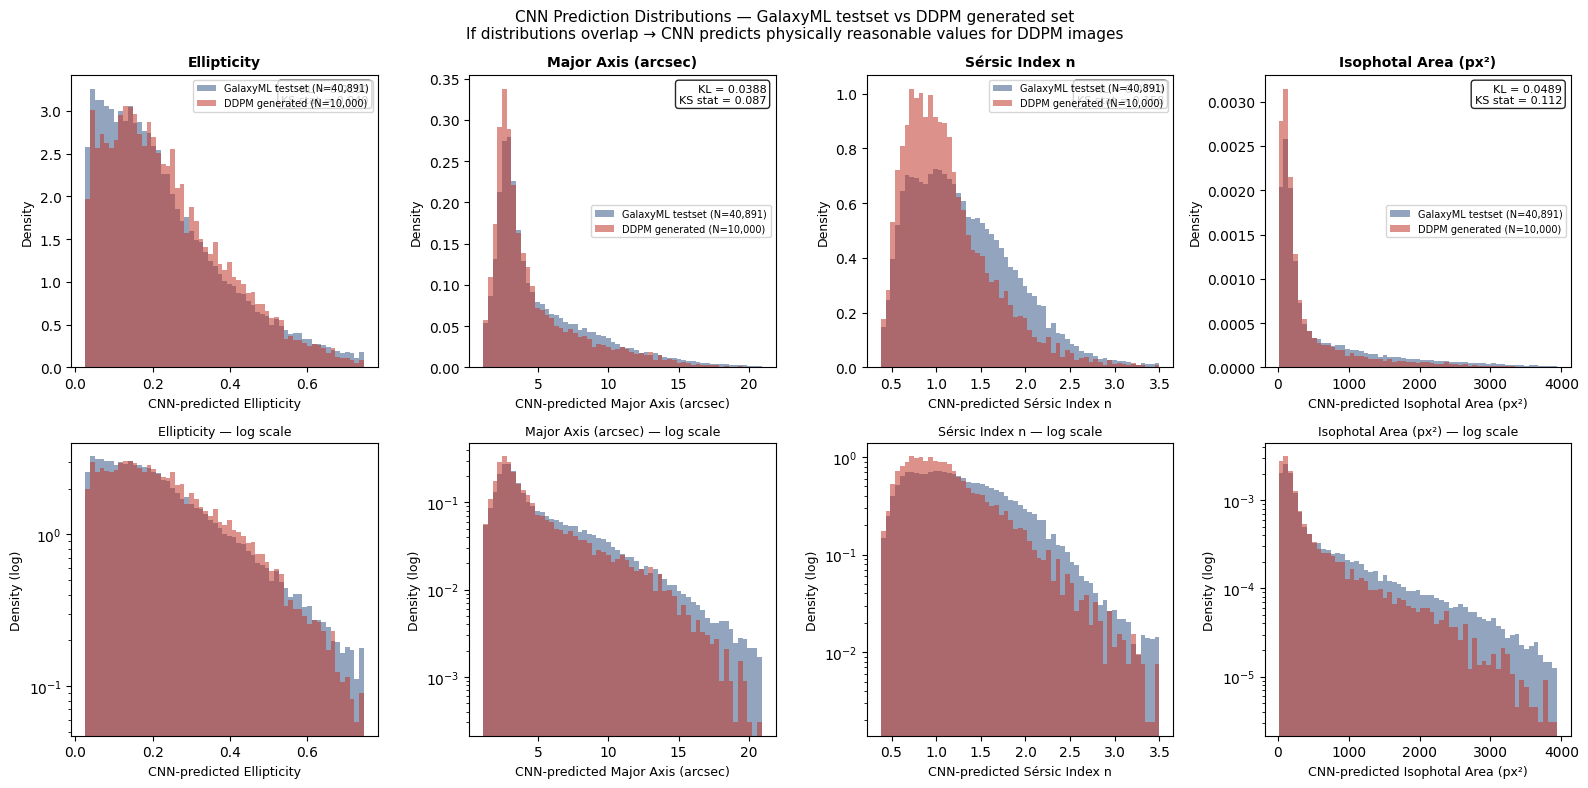

Saved pred_distribution_comparison.png

Parameter               KL divergence   KS statistic interpretation
---------------------------------------------------------------------------
  g_ellipticity                0.0100         0.0397   similar
  g_major_axis                 0.0388         0.0867   similar
  g_sersic_index               0.0740         0.1581   similar
  g_isophotal_area             0.0489         0.1119   similar


In [18]:
from scipy.special import kl_div as scipy_kl_div
from scipy.stats import ks_2samp

gen_preds_plot = np.load(os.path.join(HERE, "gen_preds.npy"))   # (10000, 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    "CNN Prediction Distributions — GalaxyML testset vs DDPM generated set\n"
    "If distributions overlap → CNN predicts physically reasonable values for DDPM images",
    fontsize=11
)

for i, (col, label, short) in enumerate(zip(TARGET_COLS, PARAM_LABELS, PARAM_SHORT)):
    gt_p   = test_preds[:, i]
    ddpm_p = gen_preds_plot[:, i]

    # KL divergence
    lo = min(np.percentile(gt_p, 0.5),  np.percentile(ddpm_p, 0.5))
    hi = max(np.percentile(gt_p, 99.5), np.percentile(ddpm_p, 99.5))
    bins = np.linspace(lo, hi, 60)
    p, _ = np.histogram(gt_p,   bins=bins, density=True)
    q, _ = np.histogram(ddpm_p, bins=bins, density=True)
    eps  = 1e-10
    p = (p + eps) / (p + eps).sum()
    q = (q + eps) / (q + eps).sum()
    kl = float(np.sum(scipy_kl_div(p, q)))

    # KS test
    ks_stat, ks_p = ks_2samp(gt_p, ddpm_p)

    # ── top row: histogram overlay ────────────────────────────────────────
    ax = axes[0, i]
    ax.hist(gt_p,   bins=bins, density=True, alpha=0.55, color="#3a5a8a",
            label=f"GalaxyML testset (N={len(gt_p):,})")
    ax.hist(ddpm_p, bins=bins, density=True, alpha=0.55, color="#c0392b",
            label=f"DDPM generated (N={len(ddpm_p):,})")
    ax.set_xlabel(f"CNN-predicted {label}", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.text(0.97, 0.97, f"KL = {kl:.4f}\nKS stat = {ks_stat:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(fc="white", alpha=0.85, boxstyle="round"))

    # ── bottom row: log scale ─────────────────────────────────────────────
    ax2 = axes[1, i]
    ax2.hist(gt_p,   bins=bins, density=True, alpha=0.55, color="#3a5a8a")
    ax2.hist(ddpm_p, bins=bins, density=True, alpha=0.55, color="#c0392b")
    ax2.set_xlabel(f"CNN-predicted {label}", fontsize=9)
    ax2.set_ylabel("Density (log)", fontsize=9)
    ax2.set_title(f"{label} — log scale", fontsize=9)
    ax2.set_yscale("log")

plt.tight_layout()
plt.savefig(os.path.join(HERE, "pred_distribution_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved pred_distribution_comparison.png")

# ── summary table ─────────────────────────────────────────────────────────
print(f"\n{'Parameter':<22} {'KL divergence':>14} {'KS statistic':>14} {'interpretation'}")
print("-" * 75)
for i, (col, label) in enumerate(zip(TARGET_COLS, PARAM_LABELS)):
    gt_p   = test_preds[:, i]
    ddpm_p = gen_preds_plot[:, i]
    lo = min(np.percentile(gt_p, 0.5),  np.percentile(ddpm_p, 0.5))
    hi = max(np.percentile(gt_p, 99.5), np.percentile(ddpm_p, 99.5))
    bins = np.linspace(lo, hi, 60)
    p, _ = np.histogram(gt_p,   bins=bins, density=True)
    q, _ = np.histogram(ddpm_p, bins=bins, density=True)
    eps  = 1e-10
    p = (p + eps) / (p + eps).sum()
    q = (q + eps) / (q + eps).sum()
    kl = float(np.sum(scipy_kl_div(p, q)))
    ks_stat, _ = ks_2samp(gt_p, ddpm_p)
    interp = "similar" if kl < 0.1 else ("moderate diff" if kl < 0.5 else "large diff")
    print(f"  {col:<20} {kl:>14.4f} {ks_stat:>14.4f}   {interp}")